# Создание классификатора сумок и обуви.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import intel_extension_for_tensorflow as itex

I0000 00:00:1778352760.804534   19121 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778352760.866493   19121 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778352762.257164   19121 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


ModuleNotFoundError: No module named 'intel_extension_for_tensorflow'

С веб-сайтов закачали примерно по 100 цветных изображений сумок и обуви, упаковал их в ZIP-архив и разместил в Dropbox.

Приведённый ниже код загружает и распаковывает этот ZIP-архив, чтобы Colab мог получить к нему доступ.

In [ ]:
#!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
#!unzip -qq handbags-shoes.zip

Разделим набор данных на обучающую, валидационную и тестовую выборки.

In [6]:
import pathlib, shutil
from itertools import islice
base_dir = pathlib.Path("./handbags-shoes")

In [7]:
#for category in ('handbags', 'shoes'):
#    fnames = list((base_dir/category).iterdir())
#    dir = base_dir / 'train' / category
#    dir.mkdir(parents=True, exist_ok = True)
    
#   for fname in fnames[:50]:
        shutil.copy(src=fname, dst=dir)

#    dir = base_dir / 'validation' / category
#    dir.mkdir(parents=True, exist_ok = True)
#    for fname in fnames[50:75]:
#        shutil.copy(src=fname, dst=dir)

#    dir = base_dir / 'test' / category
#    dir.mkdir(parents=True, exist_ok = True)
#    for fname in fnames[75:]:
#        shutil.copy(src=fname, dst=dir)
    

Приведённый выше код создаёт следующую структуру каталогов:

train/   
..handbags/         
..shoes/    
validation/    
..handbags/       
..shoes/         
test/    
..handbags/     
..shoes/   




---



---

При работе с изображениями в формате JPEG мы будем следовать следующему процессу:

1. Считывание изображений JPEG
2. Преобразование изображений JPEG в тензоры
3. Изменение их размера до стандартного (поскольку изображения, полученные путем веб-скрейпинга, могут иметь разные размеры)
5. Группировка в пакеты (мы будем использовать пакеты по 32 изображения).

К счастью, Keras предоставляет нам единую функцию, которая выполняет все эти действия за один раз! (Ref: [image manipulation functions](https://keras.io/api/preprocessing/image/))

In [9]:
train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'train',
    image_size = (224, 224),
    batch_size = 32)
validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'validation',
    image_size = (224, 224),
    batch_size = 32)
test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'test',
    image_size = (224, 224),
    batch_size = 32)

Found 96 files belonging to 2 classes.
Found 49 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


## Базовая сверточная нейронная сеть



---



---



Мы попробуем использовать простую сверточную нейронную сеть на этом наборе данных с двумя сверточными блоками.

In [12]:
input = keras.Input(shape=(224, 224, 3))
h = keras.layers.Rescaling(1./225)(input)
h = keras.layers.Conv2D(32,             # number of filters
                        kernel_size = (2, 2),  # the shape of each filter
                        activation = "relu",
                        name = "Conv_1")(h)
h = keras.layers.MaxPool2D()(h)

#second convolution layer
h = keras.layers.Conv2D(32,
                        kernel_size = (2, 2),
                        activation = "relu",
                        name = "Conv_2")(h)
h = keras.layers.MaxPool2D()(h)

h = keras.layers.Flatten()(h)

output = keras.layers.Dense(1, activation = "sigmoid")(h)
model = keras.Model(input, output)
                        

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        96,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,345 (395.88 KB)

 Trainable params: 101,345 (395.88 KB)

 Non-trainable params: 0 (0.00 B)

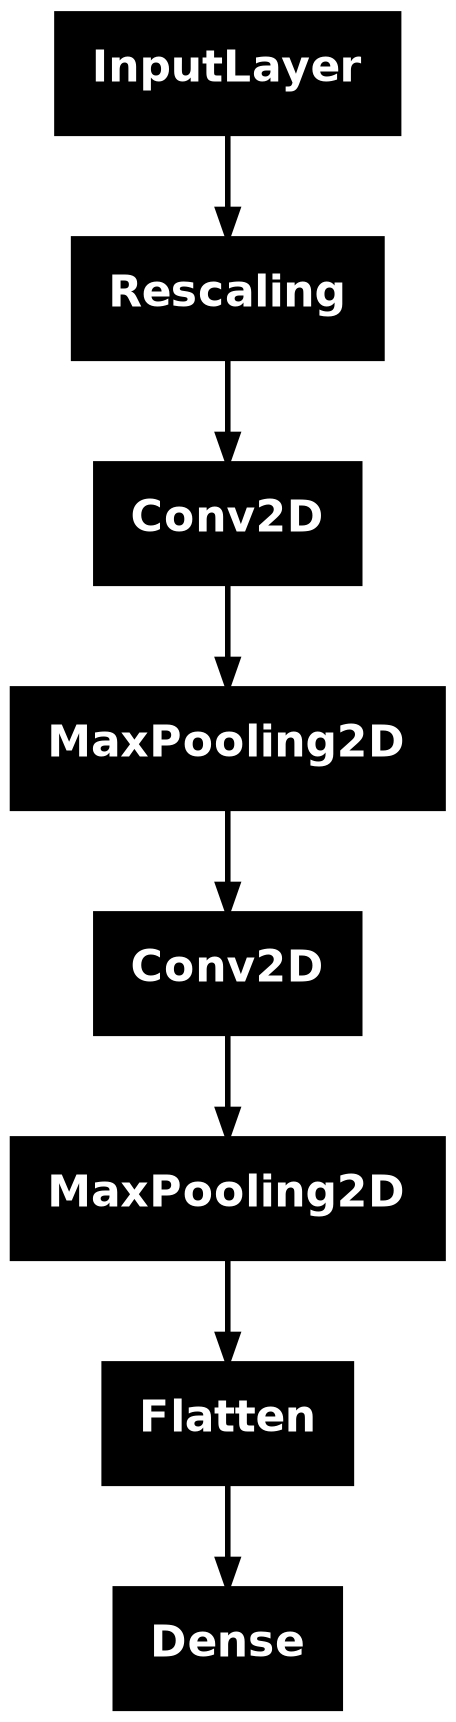

In [14]:
keras.utils.plot_model(model)

In [15]:
model.compile(loss = "binary_crossentropy",
              optimizer = "adam",
              metrics = ['accuracy'])

Как обычно, мы укажем Keras отслеживать потери и точность на **валидационном** наборе данных, чтобы следить за возможным переобучением.

Мы также будем сохранять результаты выполнения `model.fit` в переменной `history`. Это позволит нам строить графики изменения потерь и точности от эпохи к эпохе и, таким образом, оценивать возможное переобучение.

In [16]:
history = model.fit(train_dataset, 
                    epochs = 20,
                    validation_data = validation_dataset)

Epoch 1/20


W0000 00:00:1778223897.520932   29514 cpu_allocator_impl.cc:82] Allocation of 203689984 exceeds 10% of free system memory.
W0000 00:00:1778223897.790236   29514 cpu_allocator_impl.cc:82] Allocation of 50466816 exceeds 10% of free system memory.
W0000 00:00:1778223897.819491   29514 cpu_allocator_impl.cc:82] Allocation of 49561600 exceeds 10% of free system memory.
W0000 00:00:1778223897.872170   29513 cpu_allocator_impl.cc:82] Allocation of 49561600 exceeds 10% of free system memory.
W0000 00:00:1778223897.929738   29515 cpu_allocator_impl.cc:82] Allocation of 50466816 exceeds 10% of free system memory.


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5104 - loss: 1.2412 - val_accuracy: 0.5102 - val_loss: 1.6165
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6146 - loss: 0.9365 - val_accuracy: 0.4898 - val_loss: 1.1311
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 819ms/step - accuracy: 0.5417 - loss: 0.8259 - val_accuracy: 0.7347 - val_loss: 0.5473
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 996ms/step - accuracy: 0.8229 - loss: 0.4633 - val_accuracy: 0.7347 - val_loss: 0.5720
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 940ms/step - accuracy: 0.8021 - loss: 0.4602 - val_accuracy: 0.7143 - val_loss: 0.5495
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 931ms/step - accuracy: 0.9375 - loss: 0.3850 - val_accuracy: 0.7755 - val_loss: 0.5337
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 935ms/step - accuracy: 0.9479 - loss: 0.3160 - val_accuracy: 0.6735 - val_loss: 0.5378
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 936ms/step - accuracy: 0.9479 - loss: 0.2549 - val_accuracy: 0.7347 - val_loss: 0.4737
Epoch 9/2

In [20]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

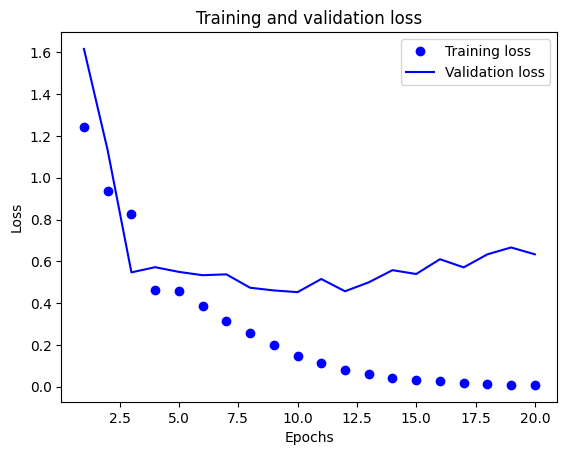

In [21]:
plot_loss_curves(history)

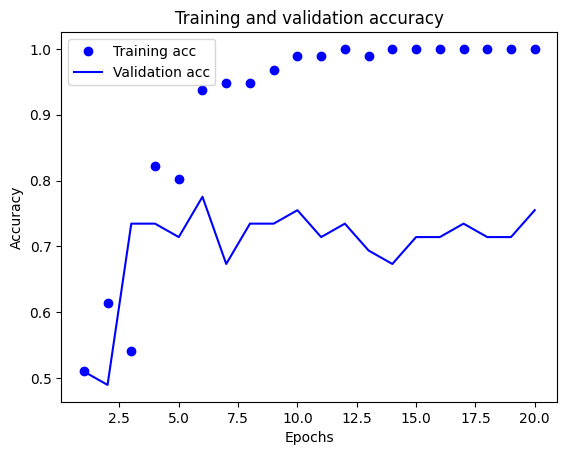

In [22]:
plot_acc_curves(history)

Модель демонстрирует высокую точность обучения. Это неудивительно, поскольку наш обучающий набор данных содержит всего около 90 примеров, в то время как наша модель имеет 101 345 параметров!

Кривая точности валидации очень зашумлена, поскольку набор данных для валидации содержит всего 49 примеров, но очевидно, что существует разрыв между кривыми точности обучения и валидации, что указывает на **переобучение**.


In [23]:
model.evaluate(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.8500 - loss: 0.5171


[0.5171151757240295, 0.8500000238418579]